## Introduction:

The goal of this project is to analyze biodiversity data from the National Parks Service, particularly around various species observed in different national park locations.

This project will scope, analyze, prepare, plot data, and seek to explain the findings from the analysis.

This Project seeks to answer the following questions:

What is the distribution of conservation status for species?
Are certain types of species more likely to be endangered?
Are the differences between species and their conservation status significant?
Which animal is most prevalent, and what is their distribution amongst parks?

Data sources:

Codecademy.com provided both Observations.csv and Species_info.csv.


## Project Goals:

This project will be conducted through the lens of a biodiversity analyst for National Parks Service. They want to ensure the survival of at-risk species, in order to maintain the level of biodiversity within their parks. The main objectives as an analyst will be to understand the characteristics of these species, their consvervation status, and their relationship to the national parks. 


## Data:

This project will use two data sets. The first csv file has information about each species and another has observations of species with park locations. This data will be used to analyze the goals of the project.

In [87]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
from itertools import chain
import string

%matplotlib inline

## Data For Species

In [88]:

species_df = pd.read_csv('species_info.csv',encoding='utf-8')
print(species_df.head())

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  


## Data for Observations

In [89]:
observations_df = pd.read_csv('observations.csv', encoding='utf-8')
print(observations_df.head())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85


## Exploring the Data

In [90]:
print(f"Number of categories: {species_df.category.nunique()}")
print(f"Categories: {species_df.category.unique()}")

Number of categories: 7
Categories: ['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']


In [91]:
species_df.groupby("category").size()

category
Amphibian              80
Bird                  521
Fish                  127
Mammal                214
Nonvascular Plant     333
Reptile                79
Vascular Plant       4470
dtype: int64

In [92]:
print(f"Number of conservation statuses: {species_df.conservation_status.nunique()}")
print(f"Unique conservation statuses: {species_df.conservation_status.unique()}")

Number of conservation statuses: 4
Unique conservation statuses: [nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


In [93]:
print(f"na values:{species_df.conservation_status.isna().sum()}")

print(species_df.groupby("conservation_status").size())

na values:5633
conservation_status
Endangered             16
In Recovery             4
Species of Concern    161
Threatened             10
dtype: int64


In [94]:
print(f"Number of parks: {observations_df.park_name.nunique()}")
print(f"Unique parks: {observations_df.park_name.unique()}")

Number of parks: 4
Unique parks: ['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


In [95]:
print(f"Number of observations: {observations_df.observations.sum()}")

Number of observations: 3314739


## Cleaning the Data 

In [96]:
species_df.fillna('No Intervention', inplace=True)
species_df.groupby("conservation_status").size()

conservation_status
Endangered              16
In Recovery              4
No Intervention       5633
Species of Concern     161
Threatened              10
dtype: int64

In [97]:
conservationCategory = species_df[species_df.conservation_status != 'No Intervention']\
    .groupby(["conservation_status", "category"])['scientific_name']\
    .count()\
    .unstack()

In [98]:
conservationCategory

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1.0,4.0,3.0,7.0,NaN,NaN,1.0
In Recovery,NaN,3.0,NaN,1.0,NaN,NaN,NaN
Species of Concern,4.0,72.0,4.0,28.0,5.0,5.0,43.0
Threatened,2.0,NaN,4.0,2.0,NaN,NaN,2.0


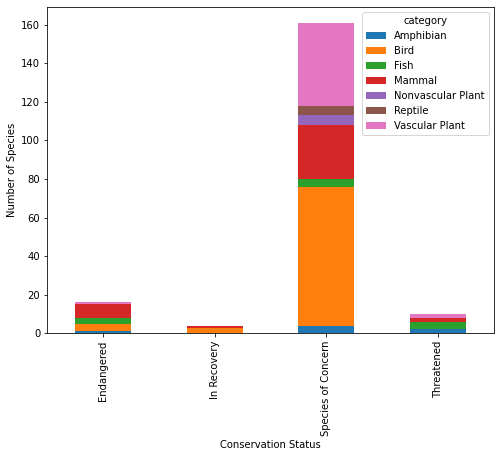

In [99]:
ax = conservationCategory.plot(kind = 'bar', figsize=(8,6), 
                               stacked=True)
ax.set_xlabel("Conservation Status")
ax.set_ylabel("Number of Species");

Notably only two species are in the recovery status, Birds and 'Mammal'. Mammals have a total of about 120 species of concern whereas birds have about 80. Vascular plants have the most species of concern and Amphibians have the lease.  Mammals have the most endangered species and reptiles have none. 

In [100]:
endangered = species_df[species_df['conservation_status'] == 'Endangered']

endangered_counts = endangered.groupby('category')['scientific_name'].nunique().reset_index()

endangered_counts.columns = ['category', 'count']
endangered_counts

,category,count
0,Amphibian,1
1,Bird,4
2,Fish,3
3,Mammal,6
4,Vascular Plant,1


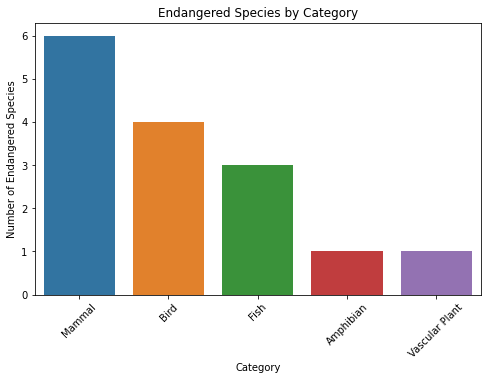

In [101]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=endangered_counts.sort_values('count', ascending=False),
    x='category',
    y='count'
)

plt.title('Endangered Species by Category')
plt.xlabel('Category')
plt.ylabel('Number of Endangered Species')
plt.xticks(rotation=45)
plt.show()

In [102]:
species_df['is_protected'] = species_df.conservation_status != 'No Intervention'

In [103]:
category_counts = species_df.groupby(['category', 'is_protected'])\
                        .scientific_name.nunique()\
                        .reset_index()\
                        .pivot(columns='is_protected',
                                      index='category',
                                      values='scientific_name')\
                        .reset_index()
category_counts.columns = ['category', 'not_protected', 'protected']

category_counts

,category,not_protected,protected
0,Amphibian,72,7
1,Bird,413,75
2,Fish,115,11
3,Mammal,146,30
4,Nonvascular Plant,328,5
5,Reptile,73,5
6,Vascular Plant,4216,46


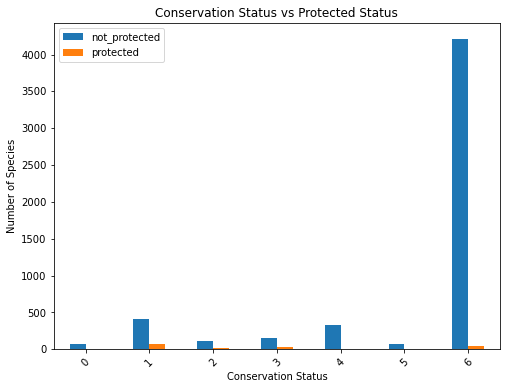

<Figure size 432x288 with 0 Axes>

In [104]:
category_counts.plot(
    kind='bar',
    figsize=(8,6)
)

plt.xlabel('Conservation Status')
plt.ylabel('Number of Species')
plt.title('Conservation Status vs Protected Status')
plt.xticks(rotation=45)
plt.show()
plt.clf()

In [105]:
category_counts['percent_protected'] = category_counts.protected / \
                                      (category_counts.protected + category_counts.not_protected) * 100

category_counts

,category,not_protected,protected,percent_protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


## Contingency Tests 

In [106]:
from scipy.stats import chi2_contingency

# Mammal and Bird
contingency1 = [[30, 146],
              [75, 413]]
chi2_contingency(contingency1)

(0.1617014831654557,
 0.6875948096661336,
 1,
 array([[ 27.8313253, 148.1686747],
        [ 77.1686747, 410.8313253]]))

In [107]:
# Bird and Vascular Plant
contingency3 = [[75, 413],
               [46, 4216]]
chi2_contingency(contingency3)

(354.42332680820607,
 4.612268031690143e-79,
 1,
 array([[  12.43115789,  475.56884211],
        [ 108.56884211, 4153.43115789]]))

In [108]:
# Amphibian and Nonvascular Plant
contingency4 = [[7, 72],
               [5, 328]]
chi2_contingency(contingency4)

(9.765103711306242,
 0.001778554820715609,
 1,
 array([[  2.30097087,  76.69902913],
        [  9.69902913, 323.30097087]]))

What this section aims to show is the statistical significance of the difference between two animal categories. a p-value higher the 0.05 is shown in Mammal and Birds and tested (deleted for redundency) Amphibians and Birds, fish, and Mammals. This higher p-value means that there is no statistically significant difference between the two animals, they are independent to each other. However in the case of Birds and Vascular plants there is a very very small p-value (e-79) meaning there is strong evidence that birds need more protection then vascular plants. 

In [109]:
# Species observed in Parks
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

common_Names = species_df[species_df.category == "Mammal"]\
    .common_names\
    .apply(remove_punctuations)\
    .str.split().tolist()

common_Names[:6]

[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison', 'Bison'],
 ['Aurochs',
  'Aurochs',
  'Domestic',
  'Cattle',
  'Feral',
  'Domesticated',
  'Cattle'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Sheep', 'Sheep', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

In [110]:
#Removing Duplicates 
cleanRows = []

for item in common_Names:
    item = list(dict.fromkeys(item))
    cleanRows.append(item)
    
cleanRows[:6]

[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison'],
 ['Aurochs', 'Domestic', 'Cattle', 'Feral', 'Domesticated'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

In [111]:
# Compressing Data 
res = list(chain.from_iterable(i if isinstance(i, list) else [i] for i in cleanRows))
res[:6]

['Gappers', 'RedBacked', 'Vole', 'American', 'Bison', 'Aurochs']

In [112]:
# Counting how many times a word occurs
words_counted = []

for i in res:
    x = res.count(i)
    words_counted.append((i,x))

pd.DataFrame(set(words_counted), columns =['Word', 'Count']).sort_values("Count", ascending = False).head(10)

,Word,Count
122,Bat,23
104,Shrew,18
82,Myotis,17
140,Mouse,16
85,Chipmunk,13
90,American,12
98,Squirrel,12
116,Eastern,11
194,Vole,11
46,Western,10


In [113]:
species_df['is_bat'] = species_df.common_names.str.contains(r"\bBat\b", regex = True)

species_df.head(10)

,category,scientific_name,common_names,conservation_status,is_protected,is_bat
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,False,False
1,Mammal,Bos bison,"American Bison, Bison",No Intervention,False,False
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Intervention,False,False
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",No Intervention,False,False
4,Mammal,Cervus elaphus,Wapiti Or Elk,No Intervention,False,False
5,Mammal,Odocoileus virginianus,White-Tailed Deer,No Intervention,False,False
6,Mammal,Sus scrofa,"Feral Hog, Wild Pig",No Intervention,False,False
7,Mammal,Canis latrans,Coyote,Species of Concern,True,False
8,Mammal,Canis lupus,Gray Wolf,Endangered,True,False
9,Mammal,Canis rufus,Red Wolf,Endangered,True,False


In [114]:
# Merging Bat Data across the 4 parks 
bat_observations = observations_df.merge(species_df[species_df.is_bat])
bat_observations

,scientific_name,park_name,observations,category,common_names,conservation_status,is_protected,is_bat
0,Lasiurus blossevillii,Bryce National Park,113,Mammal,Western Red Bat,Species of Concern,True,True
1,Lasiurus blossevillii,Great Smoky Mountains National Park,70,Mammal,Western Red Bat,Species of Concern,True,True
2,Lasiurus blossevillii,Yosemite National Park,123,Mammal,Western Red Bat,Species of Concern,True,True
3,Lasiurus blossevillii,Yellowstone National Park,221,Mammal,Western Red Bat,Species of Concern,True,True
4,Corynorhinus rafinesquii,Yosemite National Park,188,Mammal,Rafinesque's Big-Eared Bat,No Intervention,False,True
...,...,...,...,...,...,...,...,...
139,Myotis sodalis,Yellowstone National Park,68,Mammal,"Indiana Bat, Indiana Or Social Myotis",Endangered,True,True
140,Myotis leibii,Yosemite National Park,132,Mammal,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,True,True
141,Myotis leibii,Bryce National Park,84,Mammal,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,True,True
142,Myotis leibii,Great Smoky Mountains National Park,49,Mammal,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,True,True


In [115]:
# Group bat observation by park 
bat_observations.groupby('park_name').observations.sum().reset_index()

,park_name,observations
0,Bryce National Park,3433
1,Great Smoky Mountains National Park,2411
2,Yellowstone National Park,8362
3,Yosemite National Park,4786


In [116]:
bat_observations.observations.mean()

131.88888888888889

In [117]:
# Observation by park (protected status vs not) 
obs_by_park = bat_observations.groupby(['park_name', 'is_protected']).observations.sum().reset_index()
obs_by_park

,park_name,is_protected,observations
0,Bryce National Park,False,1596
1,Bryce National Park,True,1837
2,Great Smoky Mountains National Park,False,1299
3,Great Smoky Mountains National Park,True,1112
4,Yellowstone National Park,False,4044
5,Yellowstone National Park,True,4318
6,Yosemite National Park,False,2345
7,Yosemite National Park,True,2441


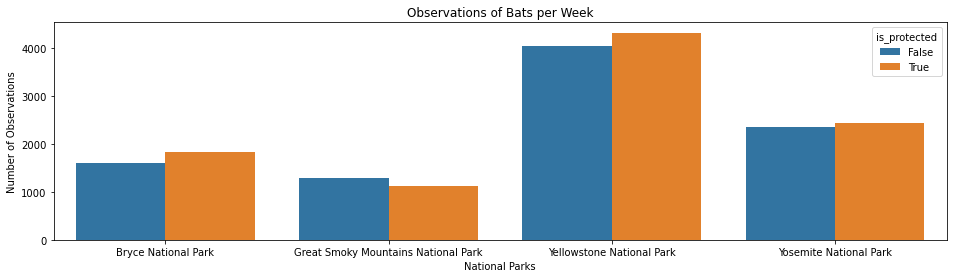

In [118]:
# Plotting Observation by park and status 
plt.figure(figsize=(16, 4))
sns.barplot(x=obs_by_park.park_name, y= obs_by_park.observations, hue=obs_by_park.is_protected)
plt.xlabel('National Parks')
plt.ylabel('Number of Observations')
plt.title('Observations of Bats per Week')
plt.show()

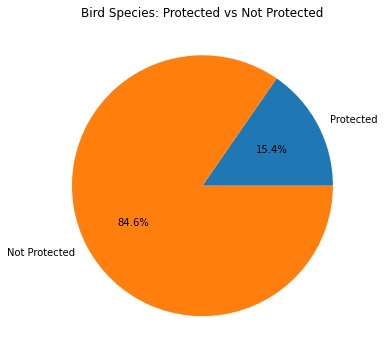

<Figure size 432x288 with 0 Axes>

In [119]:
bird_data = category_counts[category_counts['category'] == 'Bird']

protected = bird_data['protected'].iloc[0]
not_protected = bird_data['not_protected'].iloc[0]

plt.figure(figsize=(6,6))
plt.pie(
    [protected, not_protected],
    labels=['Protected', 'Not Protected'],
    autopct='%1.1f%%'
)

plt.title('Bird Species: Protected vs Not Protected')
plt.show()
plt.clf()

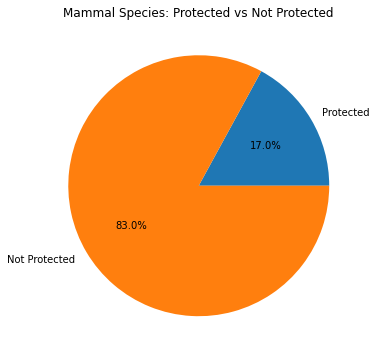

<Figure size 432x288 with 0 Axes>

In [120]:
mammal_data = category_counts[category_counts['category'] == 'Mammal']

protected = mammal_data['protected'].iloc[0]
not_protected = mammal_data['not_protected'].iloc[0]

plt.figure(figsize=(6,6))
plt.pie(
    [protected, not_protected],
    labels=['Protected', 'Not Protected'],
    autopct='%1.1f%%'
)

plt.title('Mammal Species: Protected vs Not Protected')
plt.show()
plt.clf()

## Conclusion

This project was able to make several data visualizations and inferences about the various species in four of the National Parks that comprised this data set.

Recall, the project aimed to answer the following questions:

What is the distribution of conservation status for species?
The vast majority of the documented species were not part of conservation. There were 5,633 species not in conservation vs 191 species that were. While these 5,633 species were marked as "no intervention" that does not necessarialy mean they have any population concerns. 

Are certain types of species more likely to be endangered?
While most of the listed species were likely to be endangered Mammals had the greatest chance of being endangered followed by birds. These two categories also had the most abendent unprotected species. 

Are the differences between species and their conservation status significant?
While mammals and Birds did not have significant difference in conservation percentage, Birds and vascular plants exhibited a statistically significant difference.

Which animal is most prevalent and what is their distribution amongst parks?
the study found that bats occurred the most number of times and they were most likely to be found in Yellowstone National Park. There was an average of 131.9 bat observations across all four parks

## Further Research
The data set only included observations for 7 days so there its difficult to be able to analyze significant changes over time. It would be curious to see how the conservation status for various species and how their protected status varies over. There is no specificity as to where these observations were taking place nor any sort of boundries. Yellowstone national park is a very vast park, how does is compare to other parks in terms of wildlife spotting. It would also be interesting to compare the human traffic that goes through these parks yearly and weather or not that is affecting the conservation status of some of these species. 